In [2]:
import os
import copy
import time
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = r"C:\Users\OMEN\Documents\ad infocom\Diabetic-Retinopathy-Detection-master\dr_unified_v2_clahe"

IMG_SIZE = 300
BATCH_SIZE = 12
EPOCHS = 40
PATIENCE = 5
UNFREEZE_EPOCH = 5

SAVE_DIR = "dr_results_v2"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Using device:", device)

Using device: cuda


In [4]:
#def apply_clahe(img):
#    img = np.array(img)
#    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
#    l, a, b = cv2.split(lab)
#
#    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
#    l = clahe.apply(l)
#
#    lab = cv2.merge((l, a, b))
#    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
#    return img

In [5]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [6]:
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=val_transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=val_transform)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=4, pin_memory=True)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=4, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=4, pin_memory=True)

Train: 73995
Val: 9245
Test: 9261


In [7]:
class EnsembleModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.resnet = models.resnet50(weights="IMAGENET1K_V1")
        self.effnet = models.efficientnet_b3(weights="IMAGENET1K_V1")

        self.resnet = nn.Sequential(*list(self.resnet.children())[:-1])
        self.effnet = self.effnet.features

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.fc = nn.Sequential(
            nn.Linear(2048 + 1536, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(0.5),

            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),

            nn.Linear(512, 5)
        )

    def forward(self, x):
        r = torch.flatten(self.resnet(x), 1)
        e = torch.flatten(self.pool(self.effnet(x)), 1)
        return self.fc(torch.cat((r, e), dim=1))

model = EnsembleModel().to(device)

In [8]:
for param in model.resnet.parameters():
    param.requires_grad = False

for param in model.effnet.parameters():
    param.requires_grad = False

class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5):
        super().__init__()
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

criterion = FocalLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

In [18]:
history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

best_acc = 0
patience_counter = 0

print(f"\nStarting Training for {EPOCHS} Epochs...\n")

for epoch in range(EPOCHS):

    if epoch == UNFREEZE_EPOCH:
        print("Unfreezing backbone...")
        for param in model.parameters():
            param.requires_grad = True
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model.train()
    total_loss = 0
    correct = 0
    total = 0

    start_time = time.time()

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)

    for images, labels in loop:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        # 🔥 NO MIXUP (CLEAN TRAINING)
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item())

    train_time = time.time() - start_time

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    epoch_time = time.time() - start_time

    # -------- SAVE HISTORY --------
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # -------- GPU INFO --------
    if torch.cuda.is_available():
        gpu_mem = torch.cuda.memory_allocated() / 1024**3
    else:
        gpu_mem = 0

    # -------- CLEAN SINGLE LINE OUTPUT --------
    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | "
        f"Time: {epoch_time:.1f}s | GPU: {gpu_mem:.2f}GB"
    )

    # -------- SAVE MODEL --------
    torch.save(model.state_dict(), os.path.join(SAVE_DIR, "last_model.pth"))
    np.save(os.path.join(SAVE_DIR, "history.npy"), history)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, "best_model.pth"))
        print("Best model saved")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{PATIENCE})")

    if patience_counter >= PATIENCE:
        print("Early stopping triggered")
        break

print(f"\nTraining Completed | Best Val Accuracy: {best_acc*100:.2f}%")


Starting Training for 40 Epochs...



Epoch 1/40 | Train Loss: 0.3829 | Train Acc: 77.23% | Val Loss: 0.4310 | Val Acc: 78.32% | Time: 631.7s | GPU: 0.57GB
Best model saved


Epoch 2/40 | Train Loss: 0.3723 | Train Acc: 77.55% | Val Loss: 0.6180 | Val Acc: 78.75% | Time: 634.0s | GPU: 0.57GB
Best model saved


Epoch 3/40 | Train Loss: 0.3657 | Train Acc: 77.91% | Val Loss: 3.4771 | Val Acc: 78.73% | Time: 619.1s | GPU: 0.57GB
No improvement (1/5)


Epoch 4/40 | Train Loss: 0.3611 | Train Acc: 77.91% | Val Loss: 0.4787 | Val Acc: 79.02% | Time: 598.5s | GPU: 0.57GB
Best model saved


...

Epoch 14/40 | Train Loss: 0.1858 | Train Acc: 87.66% | Val Loss: 0.2587 | Val Acc: 86.25% | Time: 1877.9s | GPU: 0.79GB
No improvement (1/5)


Epoch 15/40 | Train Loss: 0.1752 | Train Acc: 88.12% | Val Loss: 0.2872 | Val Acc: 85.91% | Time: 1995.1s | GPU: 0.79GB
No improvement (2/5)


Epoch 16/40 | Train Loss: 0.1604 | Train Acc: 88.74% | Val Loss: 0.2625 | Val Acc: 86.45% | Time: 1910.8s | GPU: 0.79GB
No improvement (3/5)


Epoch 17/40 | Train Loss: 0.1487 | Train Acc: 89.36% | Val Loss: 0.3086 | Val Acc: 86.30% | Time: 1827.1s | GPU: 0.79GB
No improvement (4/5)


Epoch 18/40 | Train Loss: 0.1390 | Train Acc: 89.86% | Val Loss: 0.9196 | Val Acc: 86.21% | Time: 1747.3s | GPU: 0.79GB
No improvement (5/5)
Early stopping triggered

Training Completed | Best Val Accuracy: 86.48%


In [11]:
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, "best_model.pth"),
                                 map_location=device, weights_only=True))
model.eval()

all_probs = []
all_labels = []

correct = 0
total = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs_list = []

        for t in [lambda x: x, lambda x: torch.flip(x, [3])]:
            out = model(t(images))
            outputs_list.append(torch.softmax(out, dim=1))

        avg_output = torch.mean(torch.stack(outputs_list), dim=0)

        preds = avg_output.argmax(1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_probs.extend(avg_output.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ✅ FINAL TEST ACCURACY
test_acc = correct / total
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# Save
np.save(os.path.join(SAVE_DIR, "test_probs.npy"), np.array(all_probs))
np.save(os.path.join(SAVE_DIR, "test_labels.npy"), np.array(all_labels))

100%|██████████| 772/772 [03:28<00:00,  3.70it/s]


Test Accuracy: 86.72%


In [9]:
history = np.load(os.path.join(SAVE_DIR, "history.npy"), allow_pickle=True).item()
probs = np.load(os.path.join(SAVE_DIR, "test_probs.npy"))
labels = np.load(os.path.join(SAVE_DIR, "test_labels.npy"))

preds = probs.argmax(1)

In [17]:
# ================= AUTO CALIBRATION =================

import numpy as np
from sklearn.metrics import balanced_accuracy_score

probs = np.load(os.path.join(SAVE_DIR, "test_probs.npy"))
labels = np.load(os.path.join(SAVE_DIR, "test_labels.npy"))

best_score = 0
best_bias = None

search_space = [1.0, 1.5, 2.0, 2.5, 3.0]

for b1 in search_space:
    for b3 in search_space:
        
        temp_probs = probs.copy()
        
        temp_probs[:, 1] *= b1
        temp_probs[:, 3] *= b3
        
        temp_probs = temp_probs / temp_probs.sum(axis=1, keepdims=True)
        
        preds = np.argmax(temp_probs, axis=1)
        
        score = balanced_accuracy_score(labels, preds)
        
        if score > best_score:
            best_score = score
            best_bias = (b1, b3)

print("Best Bias:", best_bias)
print("Best Balanced Accuracy:", best_score)

Best Bias: (3.0, 3.0)
Best Balanced Accuracy: 0.5733824751587348



=== BASIC METRICS ===
Accuracy: 0.8225
Balanced Accuracy: 0.5734
Quadratic Weighted Kappa: 0.7818
Log Loss: 0.6285

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0     0.9061    0.9432    0.9243      6896
           1     0.2244    0.3519    0.2740       466
           2     0.8019    0.4960    0.6129      1518
           3     0.2806    0.6094    0.3842       128
           4     0.8741    0.4664    0.6082       253

    accuracy                         0.8225      9261
   macro avg     0.6174    0.5734    0.5607      9261
weighted avg     0.8452    0.8225    0.8244      9261



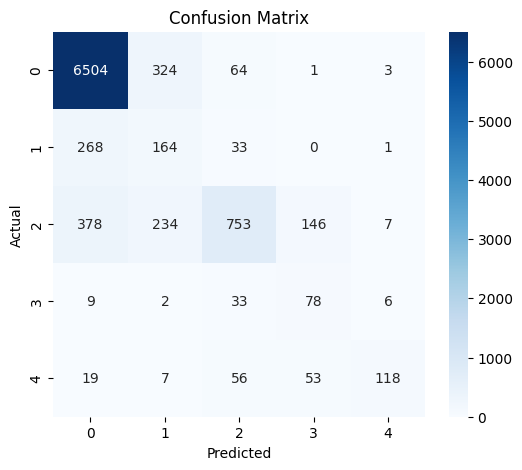

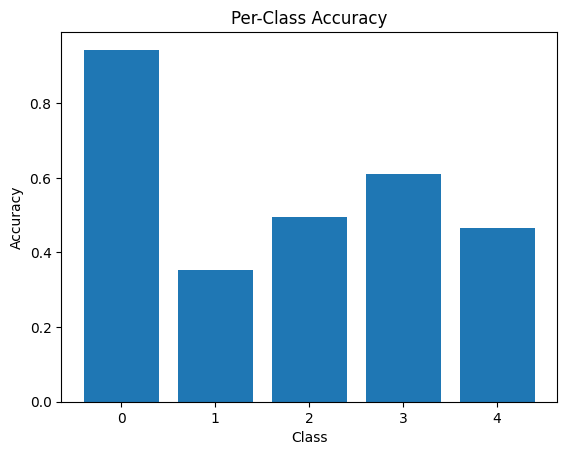


Per-class accuracy:
Class 0: 0.9432
Class 1: 0.3519
Class 2: 0.4960
Class 3: 0.6094
Class 4: 0.4664


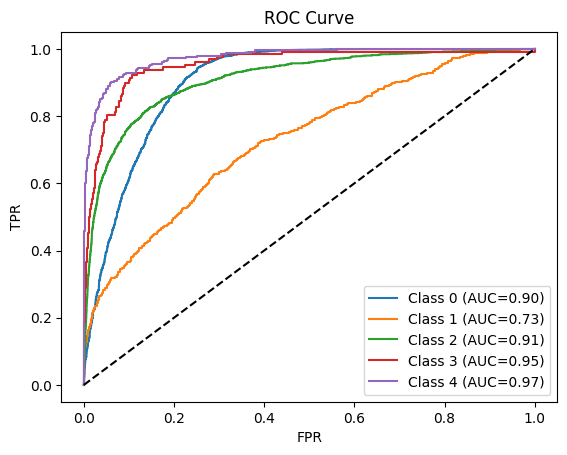

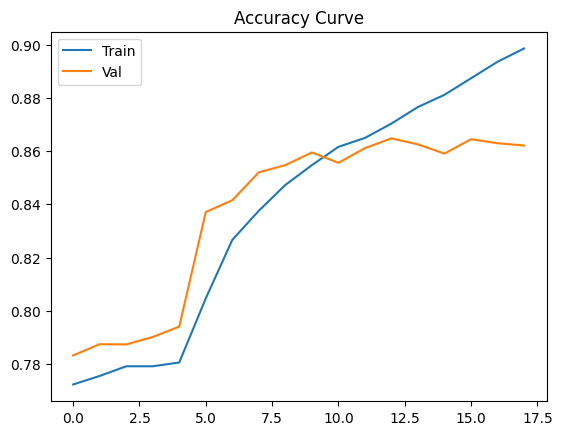

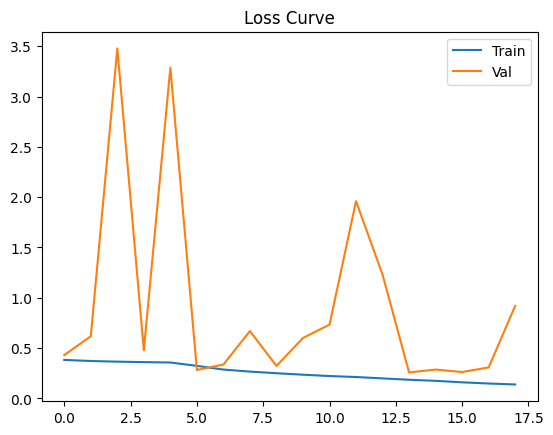

In [18]:
# ================= FINAL EVALUATION =================

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    cohen_kappa_score,
    roc_auc_score,
    log_loss,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# Apply best bias
adjusted_probs = probs.copy()

adjusted_probs[:, 1] *= best_bias[0]
adjusted_probs[:, 3] *= best_bias[1]

# Normalize
adjusted_probs = adjusted_probs / adjusted_probs.sum(axis=1, keepdims=True)

preds = np.argmax(adjusted_probs, axis=1)

# -------- METRICS --------
accuracy = accuracy_score(labels, preds)
balanced_acc = balanced_accuracy_score(labels, preds)
kappa = cohen_kappa_score(labels, preds, weights='quadratic')
ll = log_loss(labels, adjusted_probs)

print("\n=== BASIC METRICS ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Quadratic Weighted Kappa: {kappa:.4f}")
print(f"Log Loss: {ll:.4f}")

# -------- REPORT --------
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(labels, preds, digits=4))

# -------- CONFUSION MATRIX --------
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2,3,4],
            yticklabels=[0,1,2,3,4])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -------- PER CLASS --------
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure()
plt.bar([0,1,2,3,4], per_class_acc)
plt.title("Per-Class Accuracy")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.show()

print("\nPer-class accuracy:")
for i, acc in enumerate(per_class_acc):
    print(f"Class {i}: {acc:.4f}")

# -------- ROC --------
labels_bin = label_binarize(labels, classes=[0,1,2,3,4])

plt.figure()

for i in range(5):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], adjusted_probs[:, i])
    plt.plot(fpr, tpr, label=f'Class {i} (AUC={auc(fpr,tpr):.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

# -------- TRAIN CURVES --------
history = np.load(os.path.join(SAVE_DIR, "history.npy"), allow_pickle=True).item()

plt.figure()
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Val")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.title("Loss Curve")
plt.legend()
plt.show()


========== BEFORE ==========
Accuracy: 0.8671849692257856
Balanced Accuracy: 0.5276323967265044
Kappa: 0.7846258730724404

               precision    recall  f1-score   support

           0     0.8928    0.9869    0.9375      6896
           1     0.5224    0.1502    0.2333       466
           2     0.7752    0.6430    0.7029      1518
           3     0.4875    0.3047    0.3750       128
           4     0.8485    0.5534    0.6699       253

    accuracy                         0.8672      9261
   macro avg     0.7053    0.5276    0.5837      9261
weighted avg     0.8481    0.8672    0.8486      9261


Best Bias Found: (3.0, 3.0)

========== AFTER ==========
Accuracy: 0.8224813735017816
Balanced Accuracy: 0.5733824751587348
Kappa: 0.7817547906743633

               precision    recall  f1-score   support

           0     0.9061    0.9432    0.9243      6896
           1     0.2244    0.3519    0.2740       466
           2     0.8019    0.4960    0.6129      1518
           3    

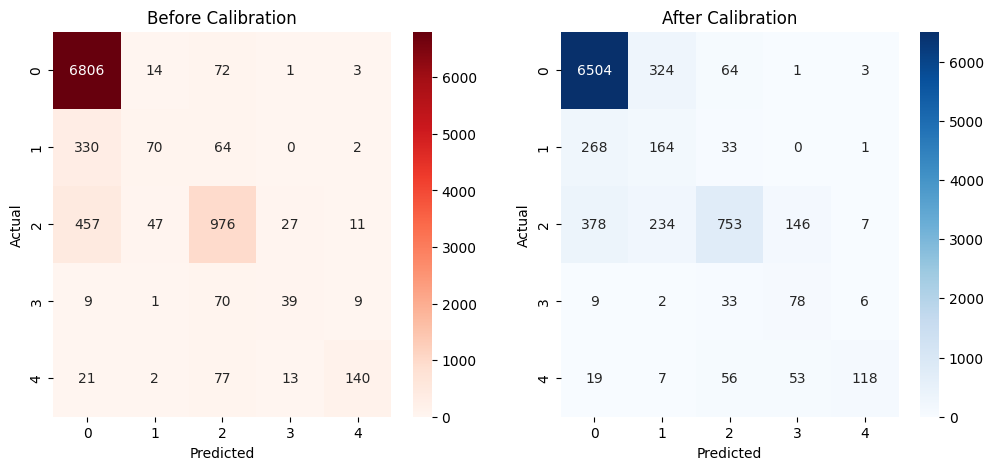

In [ ]:
import os
import copy
import time
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = r"C:\Users\OMEN\Documents\ad infocom\Diabetic-Retinopathy-Detection-master\dr_unified_v2_clahe"

IMG_SIZE = 300
BATCH_SIZE = 12
EPOCHS = 40
PATIENCE = 5
UNFREEZE_EPOCH = 5

SAVE_DIR = "dr_results_v2"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Using device:", device)
#def apply_clahe(img):
#    img = np.array(img)
#    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
#    l, a, b = cv2.split(lab)
#
#    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
#    l = clahe.apply(l)
#
#    lab = cv2.merge((l, a, b))
#    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
#    return img
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=val_transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=val_transform)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=4, pin_memory=True)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=4, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=4, pin_memory=True)
class EnsembleModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.resnet = models.resnet50(weights="IMAGENET1K_V1")
        self.effnet = models.efficientnet_b3(weights="IMAGENET1K_V1")

        self.resnet = nn.Sequential(*list(self.resnet.children())[:-1])
        self.effnet = self.effnet.features

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.fc = nn.Sequential(
            nn.Linear(2048 + 1536, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(0.5),

            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),

            nn.Linear(512, 5)
        )

    def forward(self, x):
        r = torch.flatten(self.resnet(x), 1)
        e = torch.flatten(self.pool(self.effnet(x)), 1)
        return self.fc(torch.cat((r, e), dim=1))

model = EnsembleModel().to(device)
for param in model.resnet.parameters():
    param.requires_grad = False

for param in model.effnet.parameters():
    param.requires_grad = False

class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5):
        super().__init__()
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

criterion = FocalLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)
history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

best_acc = 0
patience_counter = 0

print(f"\nStarting Training for {EPOCHS} Epochs...\n")

for epoch in range(EPOCHS):

    if epoch == UNFREEZE_EPOCH:
        print("Unfreezing backbone...")
        for param in model.parameters():
            param.requires_grad = True
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model.train()
    total_loss = 0
    correct = 0
    total = 0

    start_time = time.time()

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)

    for images, labels in loop:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        # 🔥 NO MIXUP (CLEAN TRAINING)
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item())

    train_time = time.time() - start_time

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    epoch_time = time.time() - start_time

    # -------- SAVE HISTORY --------
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # -------- GPU INFO --------
    if torch.cuda.is_available():
        gpu_mem = torch.cuda.memory_allocated() / 1024**3
    else:
        gpu_mem = 0

    # -------- CLEAN SINGLE LINE OUTPUT --------
    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | "
        f"Time: {epoch_time:.1f}s | GPU: {gpu_mem:.2f}GB"
    )

    # -------- SAVE MODEL --------
    torch.save(model.state_dict(), os.path.join(SAVE_DIR, "last_model.pth"))
    np.save(os.path.join(SAVE_DIR, "history.npy"), history)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, "best_model.pth"))
        print("Best model saved")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{PATIENCE})")

    if patience_counter >= PATIENCE:
        print("Early stopping triggered")
        break

print(f"\nTraining Completed | Best Val Accuracy: {best_acc*100:.2f}%")
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, "best_model.pth"),
                                 map_location=device, weights_only=True))
model.eval()

all_probs = []
all_labels = []

correct = 0
total = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs_list = []

        for t in [lambda x: x, lambda x: torch.flip(x, [3])]:
            out = model(t(images))
            outputs_list.append(torch.softmax(out, dim=1))

        avg_output = torch.mean(torch.stack(outputs_list), dim=0)

        preds = avg_output.argmax(1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_probs.extend(avg_output.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ✅ FINAL TEST ACCURACY
test_acc = correct / total
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# Save
np.save(os.path.join(SAVE_DIR, "test_probs.npy"), np.array(all_probs))
np.save(os.path.join(SAVE_DIR, "test_labels.npy"), np.array(all_labels))
history = np.load(os.path.join(SAVE_DIR, "history.npy"), allow_pickle=True).item()
probs = np.load(os.path.join(SAVE_DIR, "test_probs.npy"))
labels = np.load(os.path.join(SAVE_DIR, "test_labels.npy"))

preds = probs.argmax(1)
# ================= AUTO CALIBRATION =================

import numpy as np
from sklearn.metrics import balanced_accuracy_score

probs = np.load(os.path.join(SAVE_DIR, "test_probs.npy"))
labels = np.load(os.path.join(SAVE_DIR, "test_labels.npy"))

best_score = 0
best_bias = None

search_space = [1.0, 1.5, 2.0, 2.5, 3.0]

for b1 in search_space:
    for b3 in search_space:
        
        temp_probs = probs.copy()
        
        temp_probs[:, 1] *= b1
        temp_probs[:, 3] *= b3
        
        temp_probs = temp_probs / temp_probs.sum(axis=1, keepdims=True)
        
        preds = np.argmax(temp_probs, axis=1)
        
        score = balanced_accuracy_score(labels, preds)
        
        if score > best_score:
            best_score = score
            best_bias = (b1, b3)

print("Best Bias:", best_bias)
print("Best Balanced Accuracy:", best_score)
# ================= FINAL EVALUATION =================

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    cohen_kappa_score,
    roc_auc_score,
    log_loss,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# Apply best bias
adjusted_probs = probs.copy()

adjusted_probs[:, 1] *= best_bias[0]
adjusted_probs[:, 3] *= best_bias[1]

# Normalize
adjusted_probs = adjusted_probs / adjusted_probs.sum(axis=1, keepdims=True)

preds = np.argmax(adjusted_probs, axis=1)

# -------- METRICS --------
accuracy = accuracy_score(labels, preds)
balanced_acc = balanced_accuracy_score(labels, preds)
kappa = cohen_kappa_score(labels, preds, weights='quadratic')
ll = log_loss(labels, adjusted_probs)

print("\n=== BASIC METRICS ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Quadratic Weighted Kappa: {kappa:.4f}")
print(f"Log Loss: {ll:.4f}")

# -------- REPORT --------
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(labels, preds, digits=4))

# -------- CONFUSION MATRIX --------
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2,3,4],
            yticklabels=[0,1,2,3,4])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -------- PER CLASS --------
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure()
plt.bar([0,1,2,3,4], per_class_acc)
plt.title("Per-Class Accuracy")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.show()

print("\nPer-class accuracy:")
for i, acc in enumerate(per_class_acc):
    print(f"Class {i}: {acc:.4f}")

# -------- ROC --------
labels_bin = label_binarize(labels, classes=[0,1,2,3,4])

plt.figure()

for i in range(5):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], adjusted_probs[:, i])
    plt.plot(fpr, tpr, label=f'Class {i} (AUC={auc(fpr,tpr):.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

# -------- TRAIN CURVES --------
history = np.load(os.path.join(SAVE_DIR, "history.npy"), allow_pickle=True).item()

plt.figure()
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Val")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.title("Loss Curve")
plt.legend()
plt.show()
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    cohen_kappa_score
)

# -------- LOAD --------
probs = np.load(os.path.join(SAVE_DIR, "test_probs.npy"))
labels = np.load(os.path.join(SAVE_DIR, "test_labels.npy"))

# ================= BEFORE =================
preds_before = np.argmax(probs, axis=1)

print("\n========== BEFORE ==========")
print("Accuracy:", accuracy_score(labels, preds_before))
print("Balanced Accuracy:", balanced_accuracy_score(labels, preds_before))
print("Kappa:", cohen_kappa_score(labels, preds_before, weights='quadratic'))
print("\n", classification_report(labels, preds_before, digits=4))

cm_before = confusion_matrix(labels, preds_before)

# ================= AUTO CALIBRATION =================
best_score = 0
best_bias = (1.0, 1.0)

search_space = [1.0, 1.5, 2.0, 2.5, 3.0]

for b1 in search_space:
    for b3 in search_space:
        temp_probs = probs.copy()
        temp_probs[:, 1] *= b1
        temp_probs[:, 3] *= b3
        
        temp_probs = temp_probs / temp_probs.sum(axis=1, keepdims=True)
        
        preds = np.argmax(temp_probs, axis=1)
        score = balanced_accuracy_score(labels, preds)

        if score > best_score:
            best_score = score
            best_bias = (b1, b3)

print("\nBest Bias Found:", best_bias)

# ================= AFTER =================
adjusted_probs = probs.copy()

adjusted_probs[:, 1] *= best_bias[0]
adjusted_probs[:, 3] *= best_bias[1]

adjusted_probs = adjusted_probs / adjusted_probs.sum(axis=1, keepdims=True)

preds_after = np.argmax(adjusted_probs, axis=1)

print("\n========== AFTER ==========")
print("Accuracy:", accuracy_score(labels, preds_after))
print("Balanced Accuracy:", balanced_accuracy_score(labels, preds_after))
print("Kappa:", cohen_kappa_score(labels, preds_after, weights='quadratic'))
print("\n", classification_report(labels, preds_after, digits=4))

cm_after = confusion_matrix(labels, preds_after)

# ================= VISUALIZATION =================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Reds',
            xticklabels=[0,1,2,3,4],
            yticklabels=[0,1,2,3,4])
plt.title("Before Calibration")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1,2,2)
sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2,3,4],
            yticklabels=[0,1,2,3,4])
plt.title("After Calibration")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()
